# Introduction : Analyse du jeu de données MPG

Dans ce tutoriel, nous allons explorer en détail le jeu de données "mpg". Ce jeu de données, initialement publié par la bibliothèque StatLib de l'Université Carnegie Mellon et désormais disponible dans la bibliothèque Seaborn. L'objectif de ce tutoriel est d'explorer la relation entre la consommation de carburant (Miles Per Gallon, ou MPG) et diverses autres caractéristiques de ce jeu de données.

Le jeu de données "mpg" est particulièrement intéressant pour notre étude car il présente une combinaison de caractéristiques discrètes et continues. Il contient :

- 3 caractéristiques discrètes : Ces variables catégorielles nous permettront d'analyser des groupes ou des classifications au sein des données.
- 5 caractéristiques continues : Ces variables numériques nous permettront d'examiner des relations et des tendances quantitatives.

In [4]:
import seaborn as sns
# load a seaborn dataset
mpg_df = sns.load_dataset("mpg")
mpg_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


Chargement du dataset MPG...


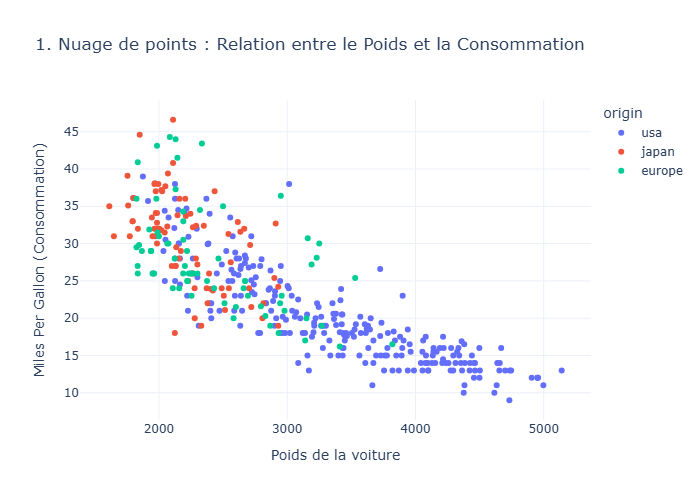

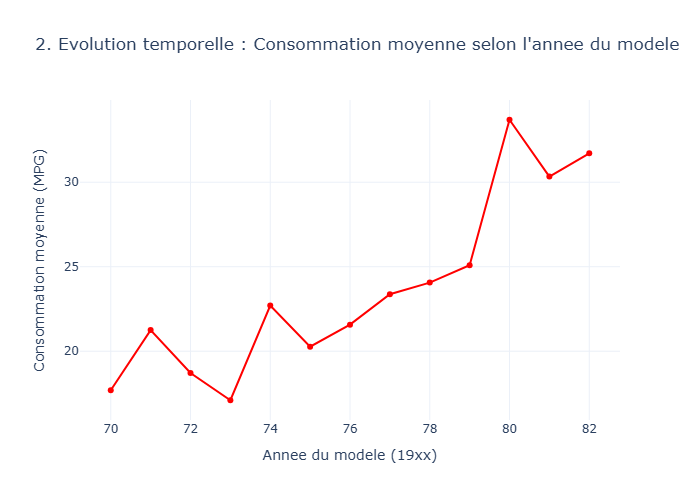

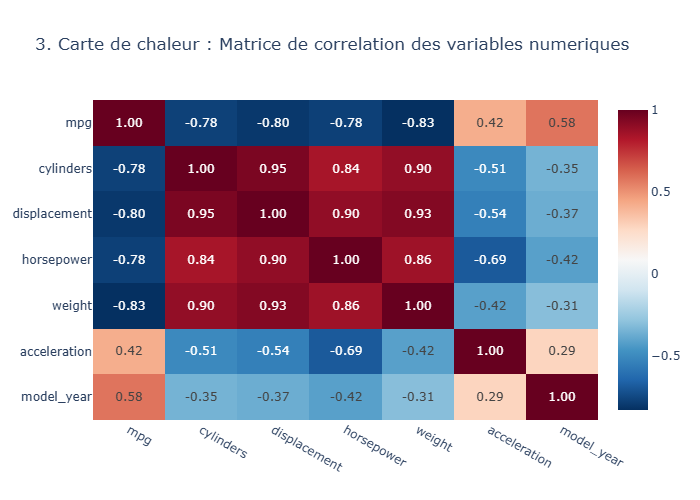

In [5]:
# --- ÉTAPE 1 : IMPORTATIONS ET CHARGEMENT ---
import seaborn as sns
import pandas as pd
import plotly.express as px
import plotly.io as pio
from IPython.display import display

# On passe en PNG pour corriger le bug de la Heatmap vide !
pio.renderers.default = "png" 

print("Chargement du dataset MPG...")
mpg_df = sns.load_dataset("mpg")

# --- ÉTAPE 2 : NUAGE DE POINTS (SCATTER PLOT) ---
fig_scatter = px.scatter(
    mpg_df, 
    x="weight", 
    y="mpg", 
    color="origin",
    hover_name="name",
    title="1. Nuage de points : Relation entre le Poids et la Consommation",
    labels={"weight": "Poids de la voiture", "mpg": "Miles Per Gallon (Consommation)"},
    template="plotly_white"
)
fig_scatter.show()

# --- ÉTAPE 3 : GRAPHIQUE EN LIGNE (LINE PLOT) ---
avg_mpg_per_year = mpg_df.groupby('model_year')['mpg'].mean().reset_index()

fig_line = px.line(
    avg_mpg_per_year, 
    x="model_year", 
    y="mpg", 
    markers=True,
    title="2. Evolution temporelle : Consommation moyenne selon l'annee du modele",
    labels={"model_year": "Annee du modele (19xx)", "mpg": "Consommation moyenne (MPG)"},
    template="plotly_white"
)
fig_line.update_traces(line_color="red")
fig_line.show()

# --- ÉTAPE 4 : CARTE DE CHALEUR (HEATMAP) ---
numeric_df = mpg_df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

fig_heatmap = px.imshow(
    corr_matrix, 
    text_auto=".2f",
    aspect="auto",
    color_continuous_scale="RdBu_r",
    title="3. Carte de chaleur : Matrice de correlation des variables numeriques"
)
fig_heatmap.show()